In [43]:
import random
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [42]:
class EmployeeOnBoardingState(TypedDict):
    emp_name: str
    emp_id: str
    joining_kit: bool
    email_id: str
    laptop_assigned: bool
    bank_acc_linked: bool
    status: str

In [48]:
def initiate_onboarding(state: EmployeeOnBoardingState):
    print("\n\n Onboarding Initiated...")
    emp_id = f"{state['emp_name'][:3]}{random.randint(300, 999)}"
    return {
        "emp_id": emp_id
    }


def infra_process(state: EmployeeOnBoardingState):
    print("Infra process Initiated...")
    email_id = f"{state['emp_id'][:4]}.{random.randint(20000, 60000)}@company.com"
    return {
        "email_id": email_id,
        "laptop_assigned": random.random() < 0.70
    }


def hr_process(_: EmployeeOnBoardingState):
    print("HR process Initiated...")
    return {
        "joining_kit": random.random() < 0.90
    }


def finance_process(_: EmployeeOnBoardingState):
    print("Finance process Initiated...")
    return {
        "bank_acc_linked": random.random() < 0.75
    }


def onboarding_verification(state: EmployeeOnBoardingState):
    print("Final Verification...")
    emp_id = state["emp_id"]
    joining_kit = state["joining_kit"]
    email_id = state["email_id"]
    laptop_assigned = state["laptop_assigned"]
    bank_acc_linked = state["bank_acc_linked"]

    onboarding_status = "Success" if all([
            emp_id,
            joining_kit,
            email_id,
            laptop_assigned,
            bank_acc_linked]) else "Pending"

    return {
        "status" : onboarding_status
    }


In [49]:
wf_state = StateGraph(EmployeeOnBoardingState)
wf_state.add_node("init", initiate_onboarding)
wf_state.add_node("infra_p", infra_process)
wf_state.add_node("hr_p", hr_process)
wf_state.add_node("finance_p", finance_process)
wf_state.add_node("verify", onboarding_verification)

wf_state.add_edge(START, "init")
wf_state.add_edge("init", "infra_p")
wf_state.add_edge("init", "hr_p")
wf_state.add_edge("init", "finance_p")

wf_state.add_edge("infra_p", "verify")
wf_state.add_edge("hr_p", "verify")
wf_state.add_edge("finance_p", "verify")

wf_state.add_edge("verify", END)

wf_graph = wf_state.compile()

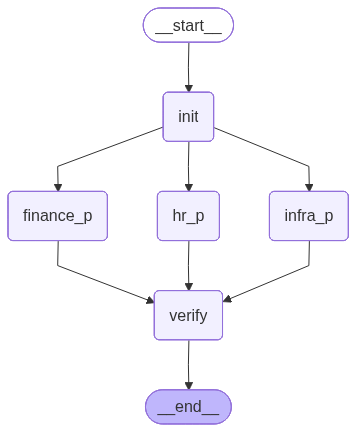

In [51]:
graph_img = display(Image(wf_graph.get_graph().draw_mermaid_png()))

In [50]:
while True:
    e_name = str(input("Employee name to Onboard - (type /bye - exit): "))
    if e_name == "/bye":
        break
    result = wf_graph.invoke(input={
        "emp_name":e_name
    })
    print(result)



 Onboarding Initiated...
Finance process Initiated...
HR process Initiated...
Infra process Initiated...
Final Verification...
{'emp_name': 'Ganesh', 'emp_id': 'Gan550', 'joining_kit': True, 'email_id': 'Gan5.22115@company.com', 'laptop_assigned': True, 'bank_acc_linked': True, 'status': 'Success'}


 Onboarding Initiated...
Finance process Initiated...
Infra process Initiated...
HR process Initiated...
Final Verification...
{'emp_name': 'Murugan', 'emp_id': 'Mur440', 'joining_kit': True, 'email_id': 'Mur4.37500@company.com', 'laptop_assigned': True, 'bank_acc_linked': True, 'status': 'Success'}


 Onboarding Initiated...
Finance process Initiated...
Infra process Initiated...
HR process Initiated...
Final Verification...
{'emp_name': 'Sivaji', 'emp_id': 'Siv630', 'joining_kit': True, 'email_id': 'Siv6.44539@company.com', 'laptop_assigned': False, 'bank_acc_linked': True, 'status': 'Pending'}
